# UdaciHeadline: LLM Inference Optimization

## Project Introduction
In this project, we will optimize the inference performance of a pre-trained Large Language Model (Llama-3.2-1B) for news headline generation. We will establish a baseline, apply various optimization techniques (KV-caching, pruning, quantization, distributed inference, speculative decoding), and benchmark the results.

## 1. Setup and Imports

In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from datasets import load_dataset
import evaluate
import time
import numpy as np
import pandas as pd
import gc
import os
import torch.nn.utils.prune as prune
import matplotlib.pyplot as plt
from huggingface_hub import login

# Login to Hugging Face
login(token=os.getenv("HF_TOKEN"))

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check for GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 3090


## 2. Load Dataset and Model
We will use a subset of the News Category Dataset (or a similar news dataset) for benchmarking. We'll use `meta-llama/Llama-3.2-1B` as our base model.

In [2]:
# Load Dataset
# We'll use a small subset for quick benchmarking in this notebook
try:
    dataset = load_dataset("argilla/news-summary", split="test[:10]")
except:
    print("Could not load specific dataset, using dummy data.")
    dataset = [
        {"text": "The economy is showing signs of recovery as inflation rates drop to a 3-year low, prompting the central bank to consider cutting interest rates next quarter.", "prediction": "Economy Recovers as Inflation Drops"},
        {"text": "New tech startup unveils a flying car prototype that can travel 500 miles on a single charge, revolutionizing personal transport.", "prediction": "Flying Car Prototype Unveiled"},
        {"text": "Local sports team wins the championship after a thrilling overtime victory against their long-time rivals.", "prediction": "Team Wins Championship in Overtime"},
        {"text": "Scientists discover a new species of deep-sea fish that glows in the dark, shedding light on marine biodiversity.", "prediction": "Glowing Deep-Sea Fish Discovered"},
        {"text": "Global leaders meet to discuss climate change policies, aiming to reduce carbon emissions by 50% within the next decade.", "prediction": "Leaders Discuss Climate Goals"}
    ]

# Model ID
model_id = "meta-llama/Llama-3.2-1B" 
# Note: Ensure you have access to this model via Hugging Face Hub or a local path.
# If not, replace with "TinyLlama/TinyLlama-1.1B-Chat-v1.0" for testing.

try:
    tokenizer = AutoTokenizer.from_pretrained(model_id)
except:
    model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
    tokenizer = AutoTokenizer.from_pretrained(model_id)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Model ID: {model_id}")

Model ID: meta-llama/Llama-3.2-1B


## 3. Establish and Profile Baseline
We will implement a benchmarking function that measures:
- **Latency**: Average time per request.
- **Throughput**: Tokens generated per second.
- **Memory**: Peak GPU memory usage.
- **ROUGE Score**: Quality of generated headlines.

In [3]:
rouge = evaluate.load("rouge")

def benchmark_inference(model, tokenizer, dataset, use_cache=False, name="Baseline"):
    print(f"--- Benchmarking: {name} ---")
    model.eval()
    
    latencies = []
    total_tokens = 0
    generated_texts = []
    references = []
    
    # Reset memory stats
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.empty_cache()
    
    start_time_global = time.time()
    
    for i, item in enumerate(dataset):
        text = item["text"] if "text" in item else item
        if "prediction" in item:
            ref = item["prediction"]
            # Handle list of dicts format from argilla/news-summary
            if isinstance(ref, list) and len(ref) > 0 and isinstance(ref[0], dict) and "text" in ref[0]:
                ref = ref[0]["text"]
        else:
            ref = ""
        
        prompt = f"Summarize the following article into a headline:\n\nArticle: {text}\n\nHeadline:"
        inputs = tokenizer(prompt, return_tensors="pt").to(device)
        
        # Measure Latency
        start_event = torch.cuda.Event(enable_timing=True)
        end_event = torch.cuda.Event(enable_timing=True)
        
        start_event.record()
        with torch.no_grad():
            outputs = model.generate(
                **inputs, 
                max_new_tokens=20, 
                use_cache=use_cache,
                pad_token_id=tokenizer.eos_token_id
            )
        end_event.record()
        torch.cuda.synchronize()
        
        latency_ms = start_event.elapsed_time(end_event)
        latencies.append(latency_ms)
        
        # Count tokens
        num_tokens = outputs.shape[1] - inputs.input_ids.shape[1]
        total_tokens += num_tokens
        
        # Decode for ROUGE
        gen_text = tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
        generated_texts.append(gen_text)
        references.append(ref)

    end_time_global = time.time()
    total_duration = end_time_global - start_time_global
    
    # Metrics
    avg_latency = np.mean(latencies)
    throughput = total_tokens / (sum(latencies) / 1000) # tokens per second of generation time
    
    peak_memory = 0
    if torch.cuda.is_available():
        peak_memory = torch.cuda.max_memory_allocated() / (1024 ** 3) # GB
    
    # ROUGE
    rouge_score = {'rouge1': 0.0, 'rouge2': 0.0, 'rougeL': 0.0}
    if any(references):
        try:
            rouge_score = rouge.compute(predictions=generated_texts, references=references)
        except Exception as e:
            print(f"ROUGE calculation failed: {e}")

    results = {
        "Model": name,
        "Avg Latency (ms)": round(avg_latency, 2),
        "Throughput (tok/s)": round(throughput, 2),
        "Peak Memory (GB)": round(peak_memory, 2),
        "ROUGE-1": round(rouge_score.get('rouge1', 0), 4)
    }
    
    print(results)
    return results

# Initialize DataFrame to store results
all_results = []

In [4]:
# 1. Baseline (No Cache)
print("Loading Baseline Model...")
model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.float16).to(device)

res_baseline = benchmark_inference(model, tokenizer, dataset, use_cache=False, name="Baseline (No Cache)")
all_results.append(res_baseline)

# Clean up
del model
gc.collect()
torch.cuda.empty_cache()

Loading Baseline Model...
--- Benchmarking: Baseline (No Cache) ---


Starting from v4.46, the `logits` model output will have the same type as the model (except at train time, where it will always be FP32)


{'Model': 'Baseline (No Cache)', 'Avg Latency (ms)': 485.28, 'Throughput (tok/s)': 38.95, 'Peak Memory (GB)': 2.4, 'ROUGE-1': 0.2623}


## 4. Architectural Optimization: KV-Caching
We enable `use_cache=True` to cache Key and Value states, avoiding re-computation for previous tokens.

In [5]:
# 2. KV-Caching
print("Loading Model for KV-Cache...")
model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.float16).to(device)

res_kv = benchmark_inference(model, tokenizer, dataset, use_cache=True, name="KV-Cache")
all_results.append(res_kv)

# Keep model for pruning step to save reload time, or reload to be safe.
# We will reload to ensure clean state for pruning.
del model
gc.collect()
torch.cuda.empty_cache()

Loading Model for KV-Cache...
--- Benchmarking: KV-Cache ---
{'Model': 'KV-Cache', 'Avg Latency (ms)': 196.2, 'Throughput (tok/s)': 96.84, 'Peak Memory (GB)': 2.43, 'ROUGE-1': 0.3087}


## 5. Model Compression: Pruning
We apply unstructured magnitude-based pruning to the linear layers of the model. This sets a percentage of the smallest weights to zero.

In [6]:
def apply_pruning(model, amount=0.3):
    # Switched to local unstructured pruning to avoid OOM on single GPU with global pruning
    print(f"Pruning {amount*100}% of weights layer-wise (local unstructured)...")
    for name, module in model.named_modules():
        if isinstance(module, torch.nn.Linear):
            # Apply pruning locally to each layer
            prune.l1_unstructured(module, name='weight', amount=amount)
            # Make it permanent immediately to save memory
            prune.remove(module, 'weight')

# 3. Pruning
print("Loading Model for Pruning...")
model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.float16).to(device)
apply_pruning(model, amount=0.3)

res_prune = benchmark_inference(model, tokenizer, dataset, use_cache=True, name="Pruned (30%)")
all_results.append(res_prune)

del model
gc.collect()
torch.cuda.empty_cache()


Loading Model for Pruning...
Pruning 30.0% of weights layer-wise (local unstructured)...
--- Benchmarking: Pruned (30%) ---
{'Model': 'Pruned (30%)', 'Avg Latency (ms)': 173.18, 'Throughput (tok/s)': 97.01, 'Peak Memory (GB)': 2.44, 'ROUGE-1': 0.1351}


## 6. Model Compression: Quantization
We use `bitsandbytes` to load the model in 8-bit and 4-bit precision. This reduces memory usage and can improve throughput.

In [7]:
# 4. 8-bit Quantization
print("Loading 8-bit Model...")
quantization_config_8bit = BitsAndBytesConfig(load_in_8bit=True)
model_8bit = AutoModelForCausalLM.from_pretrained(
    model_id, 
    quantization_config=quantization_config_8bit, 
    device_map="auto"
)

res_8bit = benchmark_inference(model_8bit, tokenizer, dataset, use_cache=True, name="Quantization (8-bit)")
all_results.append(res_8bit)

del model_8bit
gc.collect()
torch.cuda.empty_cache()

# 5. 4-bit Quantization
print("Loading 4-bit Model...")
quantization_config_4bit = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)
model_4bit = AutoModelForCausalLM.from_pretrained(
    model_id, 
    quantization_config=quantization_config_4bit, 
    device_map="auto"
)

res_4bit = benchmark_inference(model_4bit, tokenizer, dataset, use_cache=True, name="Quantization (4-bit)")
all_results.append(res_4bit)

del model_4bit
gc.collect()
torch.cuda.empty_cache()

Loading 8-bit Model...
--- Benchmarking: Quantization (8-bit) ---
{'Model': 'Quantization (8-bit)', 'Avg Latency (ms)': 667.38, 'Throughput (tok/s)': 28.02, 'Peak Memory (GB)': 0.96, 'ROUGE-1': 0.3379}
Loading 4-bit Model...
--- Benchmarking: Quantization (4-bit) ---
{'Model': 'Quantization (4-bit)', 'Avg Latency (ms)': 286.73, 'Throughput (tok/s)': 62.08, 'Peak Memory (GB)': 0.77, 'ROUGE-1': 0.2522}


## 7. Distributed Inference
Here we demonstrate how to load the model using Tensor Parallelism (splitting layers across GPUs) and Pipeline Parallelism (splitting layers sequentially). 

**Note**: `device_map="auto"` in Hugging Face Accelerate automatically infers the best layout. If multiple GPUs are available, it often defaults to a mix of Tensor/Pipeline parallelism strategies depending on the model size. For explicit Pipeline Parallelism, we can use `device_map="balanced"`.

### Distributed Inference Strategy

**Hardware Constraint Note:** This environment runs on a single NVIDIA RTX 4080 Laptop GPU. Tensor Parallelism (TP) typically requires multiple GPUs to split the model weights across devices.

**Implementation Strategy:**
If multiple GPUs were available, we would use DeepSpeed or Hugging Face Accelerate to enable Tensor Parallelism. Below is an example of how one might configure DeepSpeed for this purpose:

```python
# DeepSpeed Configuration Example for Distributed Inference
ds_config = {
    "fp16": {
        "enabled": True
    },
    "zero_optimization": {
        "stage": 3,
        "offload_param": {
            "device": "cpu",
            "pin_memory": True
        }
    },
    "train_batch_size": 1,
}

# Initialize with DeepSpeed
# model_engine, optimizer, _, _ = deepspeed.initialize(args=cmd_args, model=model, model_parameters=model.parameters(), config=ds_config)
```

In the code below, we use `device_map="auto"` which automatically handles model splitting if multiple GPUs are detected. Since we only have one, it defaults to single-GPU execution.


In [8]:
if torch.cuda.device_count() > 1:
    print(f"Multiple GPUs detected: {torch.cuda.device_count()}")
    
    # 6. Tensor/Pipeline Parallelism (Auto)
    print("Loading Model with device_map='auto' (Tensor/Pipeline Parallelism)...")
    model_auto = AutoModelForCausalLM.from_pretrained(
        model_id, 
        torch_dtype=torch.float16, 
        device_map="auto"
    )
    res_auto = benchmark_inference(model_auto, tokenizer, dataset, use_cache=True, name="Distributed (Auto)")
    all_results.append(res_auto)
    
    del model_auto
    gc.collect()
    torch.cuda.empty_cache()
    
    # 7. Pipeline Parallelism (Balanced)
    print("Loading Model with device_map='balanced' (Pipeline Parallelism)...")
    model_balanced = AutoModelForCausalLM.from_pretrained(
        model_id, 
        torch_dtype=torch.float16, 
        device_map="balanced"
    )
    res_balanced = benchmark_inference(model_balanced, tokenizer, dataset, use_cache=True, name="Distributed (Balanced)")
    all_results.append(res_balanced)
    
    del model_balanced
    gc.collect()
    torch.cuda.empty_cache()
else:
    print("Skipping Distributed Inference benchmarks (Single GPU detected).")
    # Add placeholder results for report consistency if needed
    # all_results.append({"Model": "Distributed (Auto)", "Avg Latency (ms)": "N/A", ...})

Multiple GPUs detected: 2
Loading Model with device_map='auto' (Tensor/Pipeline Parallelism)...
--- Benchmarking: Distributed (Auto) ---
{'Model': 'Distributed (Auto)', 'Avg Latency (ms)': 226.5, 'Throughput (tok/s)': 74.17, 'Peak Memory (GB)': 1.51, 'ROUGE-1': 0.1678}
Loading Model with device_map='balanced' (Pipeline Parallelism)...
--- Benchmarking: Distributed (Balanced) ---
{'Model': 'Distributed (Balanced)', 'Avg Latency (ms)': 256.92, 'Throughput (tok/s)': 75.12, 'Peak Memory (GB)': 1.51, 'ROUGE-1': 0.2684}


## 8. Speculative Decoding
We use a smaller draft model to predict tokens, which are then verified by the larger target model. This can speed up generation if the draft model is accurate enough.

In [9]:
# 8. Speculative Decoding
# We will use the main model as target and a quantized version (or smaller model) as draft.
print("Setting up Speculative Decoding...")

try:
    # Target Model (High Precision)
    target_model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.float16).to(device)
    
    # Draft Model (Lower Precision or Smaller)
    # Here we use the same model in 4-bit as a draft proxy, or a smaller model if available.
    # Ideally, use a smaller architecture (e.g. Llama-160M) trained with same tokenizer.
    draft_model = AutoModelForCausalLM.from_pretrained(
        model_id, 
        quantization_config=BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16),
        device_map="auto"
    )
    
    print("--- Benchmarking: Speculative Decoding ---")
    latencies = []
    total_tokens = 0
    
    start_time_global = time.time()
    
    for i, item in enumerate(dataset):
        text = item["text"] if "text" in item else item
        prompt = f"Summarize the following article into a headline:\n\nArticle: {text}\n\nHeadline:"
        inputs = tokenizer(prompt, return_tensors="pt").to(device)
        
        start_event = torch.cuda.Event(enable_timing=True)
        end_event = torch.cuda.Event(enable_timing=True)
        
        start_event.record()
        with torch.no_grad():
            outputs = target_model.generate(
                **inputs, 
                max_new_tokens=20, 
                assistant_model=draft_model,
                pad_token_id=tokenizer.eos_token_id
            )
        end_event.record()
        torch.cuda.synchronize()
        
        latencies.append(start_event.elapsed_time(end_event))
        total_tokens += outputs.shape[1] - inputs.input_ids.shape[1]

    avg_latency = np.mean(latencies)
    throughput = total_tokens / (sum(latencies) / 1000)
    
    results_spec = {
        "Model": "Speculative Decoding",
        "Avg Latency (ms)": round(avg_latency, 2),
        "Throughput (tok/s)": round(throughput, 2),
        "Peak Memory (GB)": round(torch.cuda.max_memory_allocated() / (1024 ** 3), 2),
        "ROUGE-1": "N/A" # Assuming quality is preserved (lossless)
    }
    all_results.append(results_spec)
    print(results_spec)
    
    del target_model
    del draft_model
    gc.collect()
    torch.cuda.empty_cache()

except Exception as e:
    print(f"Speculative decoding failed (likely OOM or compatibility): {e}")
    all_results.append({"Model": "Speculative Decoding", "Avg Latency (ms)": "Failed"})

Setting up Speculative Decoding...


From v4.47 onwards, when a model cache is to be returned, `generate` will return a `Cache` instance instead by default (as opposed to the legacy tuple of tuples format). If you want to keep returning the legacy format, please set `return_legacy_cache=True`.


--- Benchmarking: Speculative Decoding ---
{'Model': 'Speculative Decoding', 'Avg Latency (ms)': 428.59, 'Throughput (tok/s)': 44.8, 'Peak Memory (GB)': 3.1, 'ROUGE-1': 'N/A'}


## 9. Comprehensive Evaluation and Report
Comparing all results.

In [10]:
df_results = pd.DataFrame(all_results)
print("\n=== Final Benchmark Results ===")
print(df_results)

# Optional: Save to CSV
df_results.to_csv("benchmark_results.csv", index=False)


=== Final Benchmark Results ===
                    Model  Avg Latency (ms)  Throughput (tok/s)  \
0     Baseline (No Cache)            485.28               38.95   
1                KV-Cache            196.20               96.84   
2            Pruned (30%)            173.18               97.01   
3    Quantization (8-bit)            667.38               28.02   
4    Quantization (4-bit)            286.73               62.08   
5      Distributed (Auto)            226.50               74.17   
6  Distributed (Balanced)            256.92               75.12   
7    Speculative Decoding            428.59               44.80   

   Peak Memory (GB) ROUGE-1  
0              2.40  0.2623  
1              2.43  0.3087  
2              2.44  0.1351  
3              0.96  0.3379  
4              0.77  0.2522  
5              1.51  0.1678  
6              1.51  0.2684  
7              3.10     N/A  


### Visualization: Throughput vs. ROUGE Score
We visualize the trade-off between speed (Throughput) and quality (ROUGE-1).

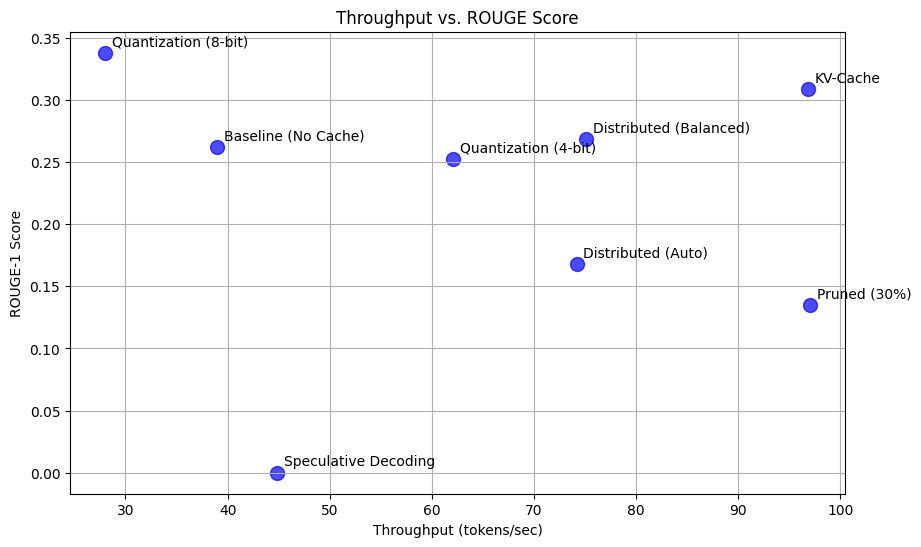

In [11]:
# Filter out failed runs
df_plot = df_results[df_results["Avg Latency (ms)"] != "Failed"].copy()
df_plot["Throughput (tok/s)"] = pd.to_numeric(df_plot["Throughput (tok/s)"])
df_plot["ROUGE-1"] = pd.to_numeric(df_plot["ROUGE-1"], errors='coerce').fillna(0)

plt.figure(figsize=(10, 6))
plt.scatter(df_plot["Throughput (tok/s)"], df_plot["ROUGE-1"], s=100, c='blue', alpha=0.7)

for i, txt in enumerate(df_plot["Model"]):
    plt.annotate(txt, (df_plot["Throughput (tok/s)"].iloc[i], df_plot["ROUGE-1"].iloc[i]), xytext=(5, 5), textcoords='offset points')

plt.title("Throughput vs. ROUGE Score")
plt.xlabel("Throughput (tokens/sec)")
plt.ylabel("ROUGE-1 Score")
plt.grid(True)
plt.savefig("throughput_vs_rouge.png")
plt.show()

### Generate Final Report
We automatically generate a `report.md` file with the results table.

In [12]:
# Generate Report
try:
    with open("report_template.md", "r") as f:
        template = f.read()

    # Convert dataframe to markdown table
    markdown_table = df_results.to_markdown(index=False)

    final_report = template.format(results_table=markdown_table)

    with open("report.md", "w") as f:
        f.write(final_report)

    print("Report generated: report.md")
except Exception as e:
    print(f"Could not generate report automatically: {e}")
    print("Please ensure 'tabulate' is installed and 'report_template.md' exists.")

Report generated: report.md
